In [6]:
technique = 'atacseq'
data_path = f"../data/ATACseq"
root_save_path = f"../saved_results/{technique}_new_trans_finetune_v2"
test_batches = ['s1d1', 's1d2', 's1d3', 's2d1', 's2d4', 's2d5', 's3d3', 's3d6', 's3d7',
       's3d10', 's4d1', 's4d8', 's4d9']
device = "cpu"

In [7]:
import scanpy as sc
adata_atac = sc.read_h5ad(f'{data_path}/atac_processed.h5ad')
adata_atac.X = adata_atac.X.toarray()
adata_atac.obs['label'] = list(adata_atac.obs['cell_type'])
adata_gex  = sc.read_h5ad(f'{data_path}/gex_processed.h5ad')
adata_gex.obs['label'] = list(adata_gex.obs['cell_type'])

def split_data(test_batch):
    adata_atac_train = adata_atac[adata_atac.obs['batch']!=test_batch]
    adata_atac_test  = adata_atac[adata_atac.obs['batch']==test_batch]

    adata_gex_train = adata_gex[adata_gex.obs['batch']!=test_batch]
    adata_gex_test  = adata_gex[adata_gex.obs['batch']==test_batch]

    return [adata_atac_train, adata_gex_train], [adata_atac_test, adata_gex_test]

##### Train

In [8]:
import sys
sys.path.append('..')
from src.interface import UnitedNet
from src.configs import *

In [ ]:
for test_batch in test_batches:
    print(test_batch)
    adatas_train, adatas_test = split_data(test_batch)
    model = UnitedNet(f"{root_save_path}/{test_batch}", device=device, technique=atacseq_config)
    model.train(adatas_train, verbose=True)
    model.finetune(adatas_train, verbose=True)
    model.transfer(adatas_train, adatas_transfer = adatas_test, verbose=True)
    print(model.evaluate(adatas_test))


s1d1
training


  0%|                                                                                            | 0/10 [00:00<?, ?it/s]



Losses                         Value
-------------------------  ---------
cross_entropy_loss_head_0  0.0481585
best_head                  0
best model saved at ../saved_results/atacseq_new_trans_finetune_v2/s1d1/train_best.pt 

model saved at ../saved_results/atacseq_new_trans_finetune_v2/s1d1/train_epoch_1.pt 



/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/tabulate/__init__.py:108: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  or (len(row) >= 2 and row[1] == SEPARATING_LINE)
 10%|████████▎                                                                          | 1/10 [04:02<36:20, 242.29s/it]



Metrics    Value
---------  -------------------------------------------------------------------------
r2         [[-0.01031906 -0.0208332 ]
            [ 0.00741964  0.00925881]]
confusion  [[ 1684     0     0     0     0     0     0     0     0     0     0     0
                 0     0     0     3     0     2     0     0     0     0]
            [    0  9841    11     0     1     2     0     0    33     0     5     0
                 0     0     0     0     0     0     1     0    28     0]
            [    0    13  1812     0     0     0     0     0     0     0     0     0
                 0     1     0     0     0     0     0     0     1     1]
            [    0     0     0  4433   121   126     0     0     0     0     0    10
                 0     0     0     0     0     0     0     0     0     0]
            [    0     0     0    51  3758     9    32     0     0     0     0     0
                 0     0     1     1     1     1     0     1     0     0]
            [    1     7

...



Metrics    Value
---------  -------------------------------------------------------------------------
r2         [[0.04503678 0.02190483]
            [0.07645898 0.08190094]]
confusion  [[ 1689     0     0     0     0     0     0     0     0     0     0     0
                 0     0     0     0     0     0     0     0     0     0]
            [    0  9922     0     0     0     0     0     0     0     0     0     0
                 0     0     0     0     0     0     0     0     0     0]
            [    0     0  1828     0     0     0     0     0     0     0     0     0
                 0     0     0     0     0     0     0     0     0     0]
            [    0     0     0  4690     0     0     0     0     0     0     0     0
                 0     0     0     0     0     0     0     0     0     0]
            [    0     0     0     0  3855     0     0     0     0     0     0     0
                 0     0     0     0     0     0     0     0     0     0]
            [    0     0    

/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/tabulate/__init__.py:108: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  or (len(row) >= 2 and row[1] == SEPARATING_LINE)
100%|████████████████████████████████████████████████████████████████████████████████| 20/20 [1:09:01<00:00, 207.10s/it]



Metrics    Value
---------  -------------------------------------------------------------------------
r2         [[0.04193711 0.02184657]
            [0.07515314 0.08095364]]
confusion  [[ 1689     0     0     0     0     0     0     0     0     0     0     0
                 0     0     0     0     0     0     0     0     0     0]
            [    0  9922     0     0     0     0     0     0     0     0     0     0
                 0     0     0     0     0     0     0     0     0     0]
            [    0     0  1828     0     0     0     0     0     0     0     0     0
                 0     0     0     0     0     0     0     0     0     0]
            [    0     0     0  4689     0     1     0     0     0     0     0     0
                 0     0     0     0     0     0     0     0     0     0]
            [    0     0     0     0  3855     0     0     0     0     0     0     0
                 0     0     0     0     0     0     0     0     0     0]
            [    0     0    

{'r2': array([[0.02937034, 0.02087941],
       [0.07922094, 0.08671795]]), 'confusion': array([[153,   1,   0,   1,   2,   0,   0,   0,   0,   0,   0,   0,   3,
          0,   0,  19,   0,  22,   0,   0,   0,   0],
       [  0, 886,   6,   0,   0,   0,   0,   0,  15,   0,   0,   0,   1,
          0,   0,   0,   0,   0,   0,   0,  13,   0],
       [  0,   3,  63,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   1,   0, 439, 375,  14,   0,   0,   0,   0,   0,   4,   0,
          0,   1,   0,   0,   2,   0,   0,   0,   0],
       [  0,   0,   2,  31, 465,   1,  37,   0,   0,   1,   0,   3,   1,
          1,   0,   0,   0,   0,   1,   0,   0,   0],
       [  0,   2,   0, 107,  42, 552,   0,   0,   1,   1,   0,  16,   0,
          1,   3,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 

  0%|                                                                                            | 0/10 [00:00<?, ?it/s]

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [10]:
!pip install importlib-metadata

/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


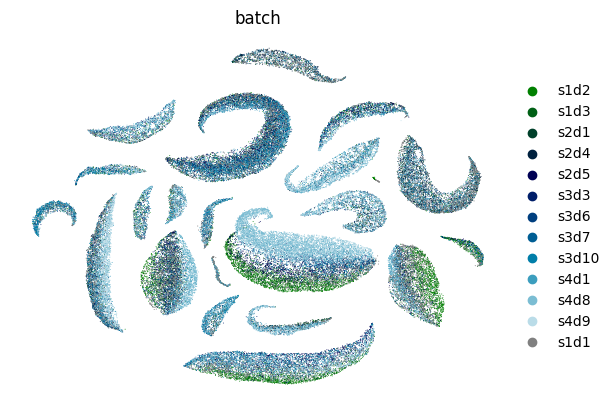

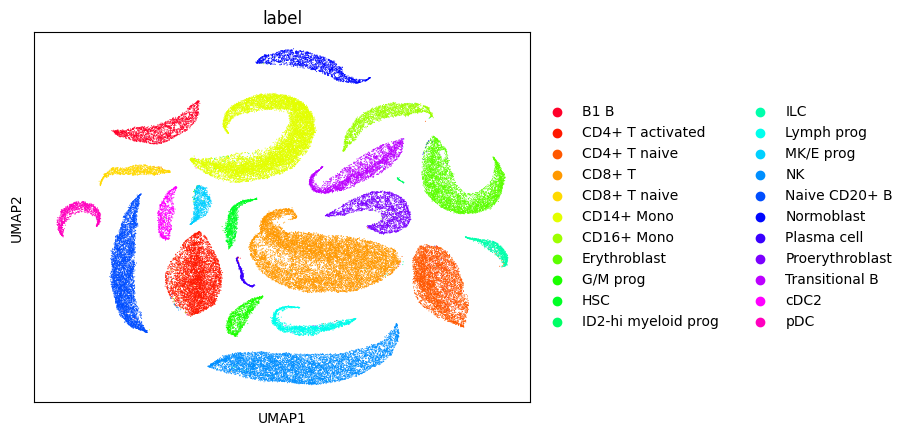

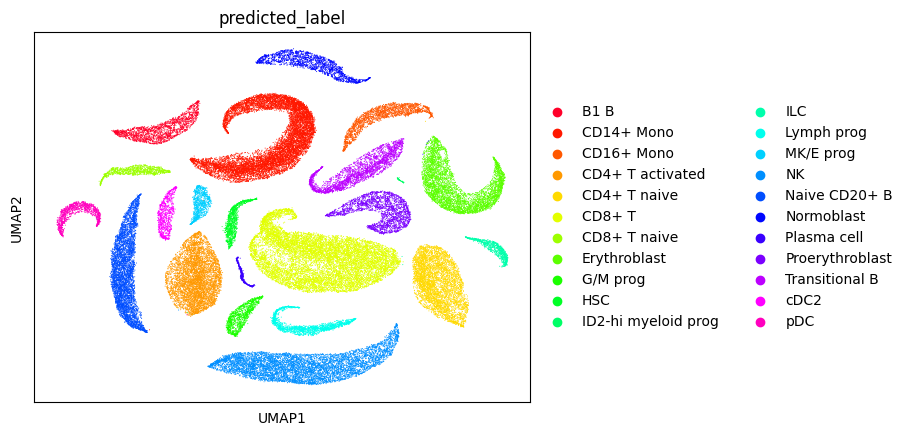

/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


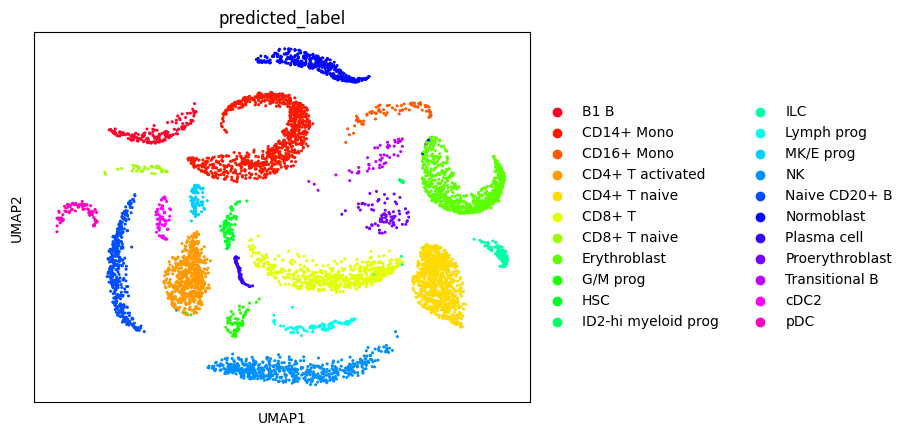

In [12]:
## need to change anaconda3/envs/UnitedNet/lib/python3.7/site-packages/umap/__init__.py the 36th row
# from importlib.metadata import version, PackageNotFoundError --> from importlib_metadata import version, PackageNotFoundError
import scanpy as sc
import torch
for test_batch in ['s1d1']:
    model = UnitedNet(f"{root_save_path}/{test_batch}", device=device, technique=atacseq_config)
    model.load_model(f"{root_save_path}/{test_batch}/transfer_best.pt",device=torch.device(device))
    model.model.device_in_use = device
    adatas = [adata_atac, adata_gex]
    adata_all = model.infer(adatas)
    adata_all.obs['batch'] = list(adatas[0].obs['batch'])
    adata_all.obs['label'] = list(adatas[0].obs['label'])

    cmap_wt = plt.get_cmap('ocean')
    new_cmap = list(cmap_wt(np.linspace(0, 0.91, 12)))
    size_umap = 120000 / adatas[0].shape[0]

    fig,ax=plt.subplots()
    ax = sc.pl.umap(adata_all[adata_all.obs['batch']!=test_batch],color=['batch'],size=size_umap,frameon = False,palette=new_cmap,ax=ax,show=False)
    sc.pl.umap(adata_all[adata_all.obs['batch']==test_batch],color=['batch'],size=size_umap*1.2,frameon = True,palette=['grey'],
               ax=ax,save=f'ATACseq_{test_batch}_batch_label.pdf')

    fig,ax=plt.subplots()
    sc.pl.umap(adata_all,color=['label'],size=size_umap*1.2,frameon = True,palette='gist_rainbow',
               ax=ax,save=f'ATACseq_{test_batch}_gt_label.pdf')

    fig,ax=plt.subplots()
    sc.pl.umap(adata_all,color=['predicted_label'],size=size_umap*1.2,frameon = True,palette='gist_rainbow',
               ax=ax,save=f'ATACseq_{test_batch}_predict_label.pdf')
    fig,ax=plt.subplots()
    sc.pl.umap(adata_all[adata_all.obs['batch']==test_batch],color=['predicted_label'],frameon = True,palette='gist_rainbow',
           ax=ax,save=f'ATACseq_{test_batch}_batch_label_test.pdf')

/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


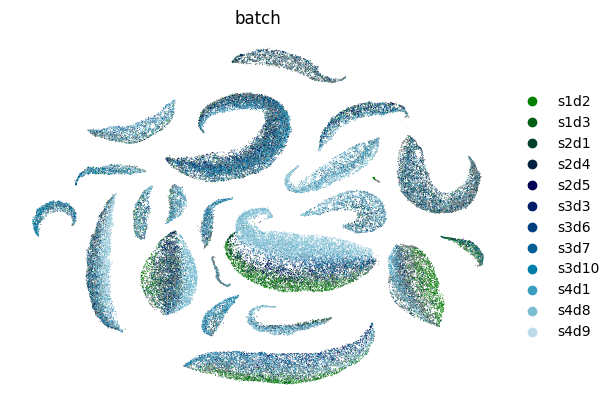

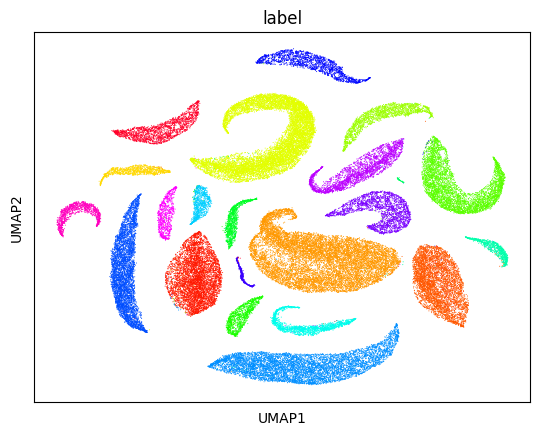

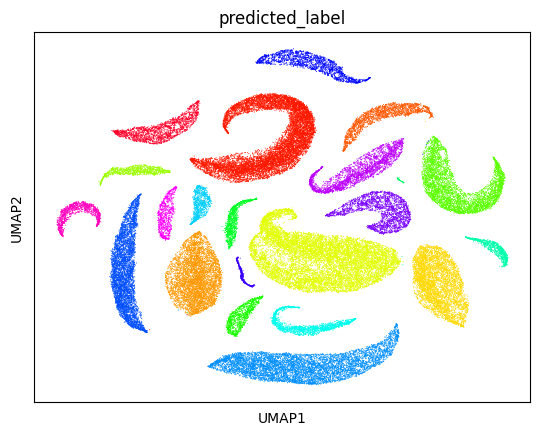

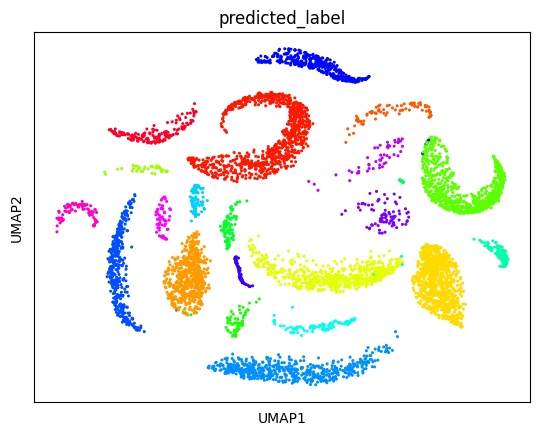

In [13]:
import matplotlib
matplotlib.rcParams['savefig.dpi'] = 1200
fig,ax=plt.subplots()
ax = sc.pl.umap(adata_all[adata_all.obs['batch']!=test_batch],color=['batch'],size=size_umap,frameon = False,palette=new_cmap,ax=ax,show=False)
sc.pl.umap(adata_all[adata_all.obs['batch']==test_batch],color=['batch'],size=size_umap*1.2,frameon = True,palette=['grey'],
           ax=ax,save=f'ATACseq_{test_batch}_batch_label.png',legend_loc =None)

fig,ax=plt.subplots()
sc.pl.umap(adata_all,color=['label'],size=size_umap*1.2,frameon = True,palette='gist_rainbow',
           ax=ax,save=f'ATACseq_{test_batch}_gt_label.png',legend_loc =None)

fig,ax=plt.subplots()
sc.pl.umap(adata_all,color=['predicted_label'],size=size_umap*1.2,frameon = True,palette='gist_rainbow',
           ax=ax,save=f'ATACseq_{test_batch}_predict_label.png',legend_loc =None)
fig,ax=plt.subplots()
sc.pl.umap(adata_all[adata_all.obs['batch']==test_batch],color=['predicted_label'],frameon = True,palette='gist_rainbow',
       ax=ax,save=f'ATACseq_{test_batch}_batch_label_test.png',legend_loc =None)

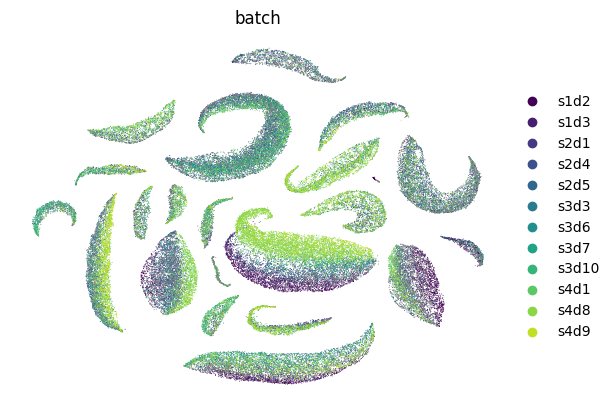

In [14]:
cmap_wt = plt.get_cmap('viridis')
new_cmap = list(cmap_wt(np.linspace(0, 0.91, 12)))
fig,ax=plt.subplots()
ax = sc.pl.umap(adata_all[adata_all.obs['batch']!=test_batch],color=['batch'],size=size_umap,frameon = False,palette=new_cmap,ax=ax,show=False)
sc.pl.umap(adata_all[adata_all.obs['batch']==test_batch],color=['batch'],size=size_umap*1.2,frameon = True,palette=['grey'],
           ax=ax,save=f'ATACseq_{test_batch}_batch_label.png',legend_loc =None)


/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


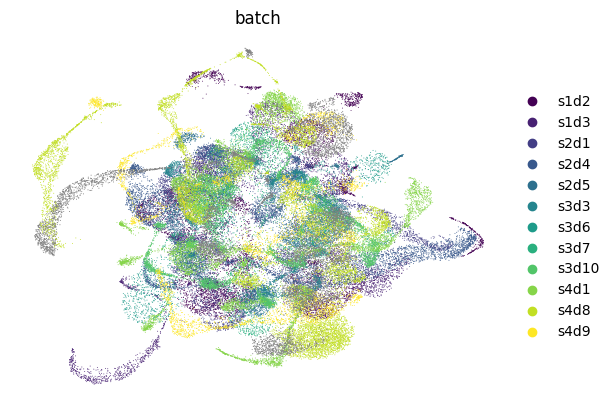

In [15]:

cmap_wt = plt.get_cmap('viridis')
new_cmap = list(cmap_wt(np.linspace(0, 1, 12)))
fig,ax=plt.subplots()
ax = sc.pl.umap(adata_atac[adata_atac.obs['batch']!=test_batch],color=['batch'],size=size_umap,frameon = False,palette=new_cmap,ax=ax,show=False)
sc.pl.umap(adata_atac[adata_atac.obs['batch']==test_batch],color=['batch'],size=size_umap*1.2,frameon = True,palette=['grey'],
           ax=ax,save=f'ATACseq_{test_batch}_batch_label_atac_only.png',legend_loc =None)


/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


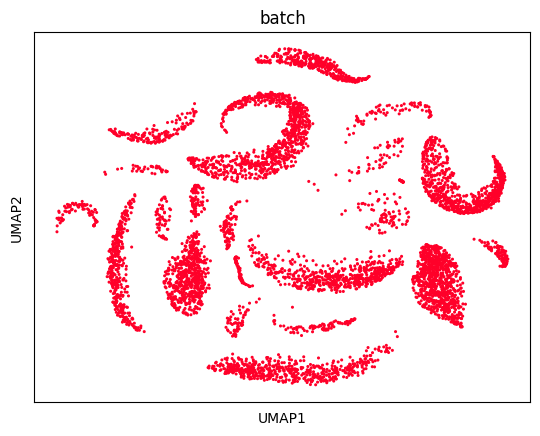

In [16]:
fig,ax=plt.subplots()
sc.pl.umap(adata_all[adata_all.obs['batch']==test_batch],color=['batch'],frameon = True,palette='gist_rainbow',
       ax=ax,save=f'ATACseq_{test_batch}_batch_label_test_colored_batch.png',legend_loc =None)

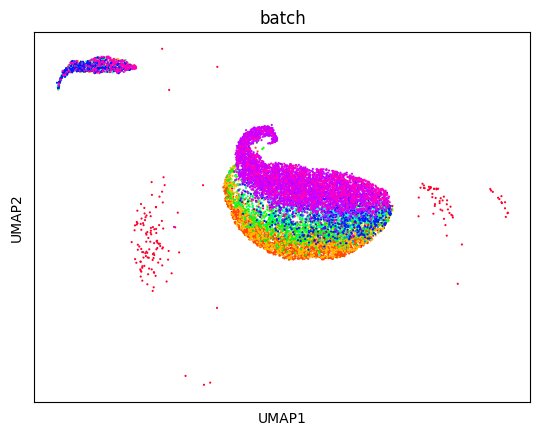

In [17]:
fig,ax=plt.subplots()
sc.pl.umap(adata_all[adata_all.obs['label'].isin(['CD8+ T','CD8+ T naive'])],color=['batch'],frameon = True,palette='gist_rainbow',
       ax=ax,save=f'ATACseq_{test_batch}_CD8T_position.png',legend_loc =None)

In [19]:
import pandas as pd
adata_atac.var_names = np.append(pd.read_csv(f'../data/ATACseq/annotated_ATAC_gene_names_10k.csv').iloc[:,0].values,'unknown')
adata_atac.var_names_make_unique()
adata_atac.var_names = adata_atac.var_names.astype(str)

CD8_T_cells


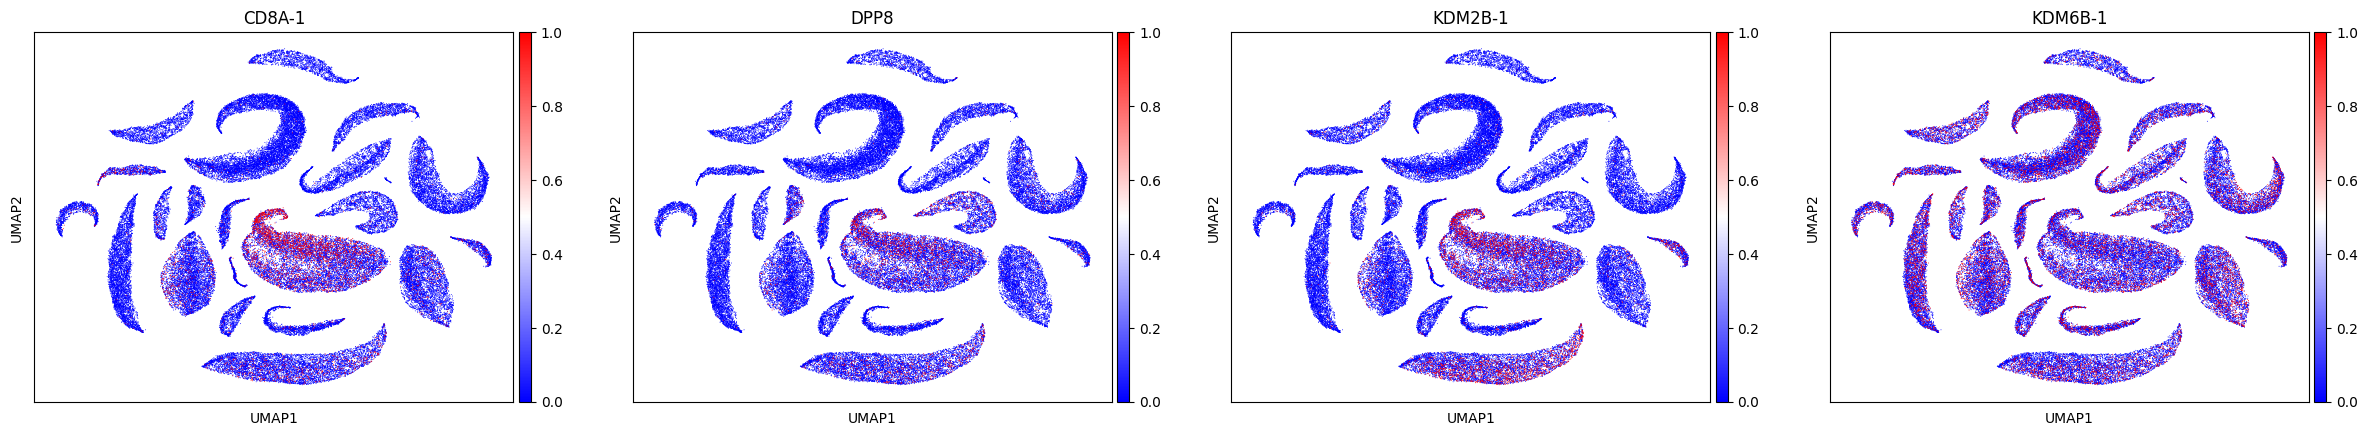

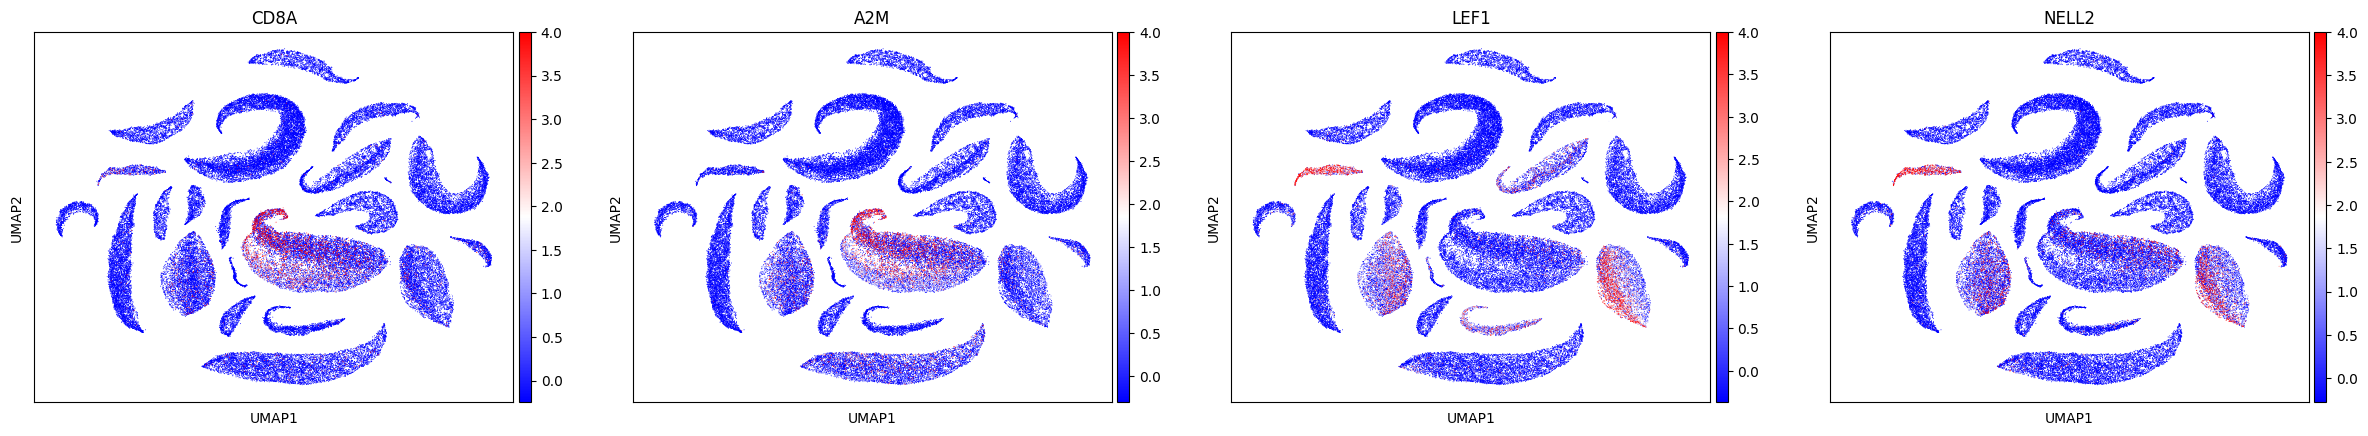

In [20]:
adatas_all_orig = [adata_atac,adata_gex]
cd8t_specific = [
    ['CD8A-1','DPP8','KDM2B-1','KDM6B-1'],
    ['CD8A','A2M','LEF1','NELL2'],
]
mods = ['ATAC','Gene']
for mjt in ['CD8_T_cells']:
    print(mjt)
    for ii in range(2):
        adata_all.obs[cd8t_specific[ii]] = adatas_all_orig[ii][:,cd8t_specific[ii]].X
        sc.pl.umap(adata_all,color=cd8t_specific[ii],cmap='bwr',show=True,save=f'{mjt}_{mods[ii]}.png')


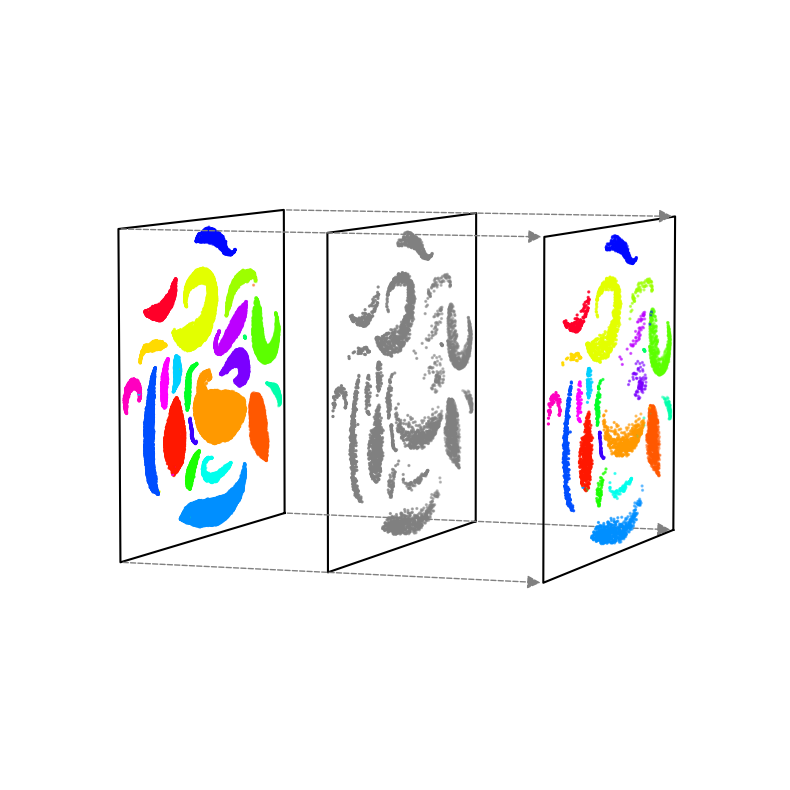

In [21]:
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))

        return np.min(zs)
from matplotlib.colors import to_hex
type_cl_dict = {}
batch_name = test_batch
for x,y in zip(adata_all[adata_all.obs['batch']!=batch_name].obs['label'].astype('category').cat.categories,
               plt.get_cmap('gist_rainbow')(np.linspace(0, 1, len(adata_all.obs['label'].unique()))).tolist()):
    type_cl_dict[x] = to_hex(y)


new_cmap = adata_all[adata_all.obs['batch']!=batch_name].obs['label'].map(type_cl_dict).values
new_cmap_bct = adata_all[adata_all.obs['batch']==batch_name].obs['predicted_label'].map(type_cl_dict).values

size_umap = 120000 / adatas[0].shape[0]
                                                                                    
fig = plt.figure(figsize=[20,10])
ax = plt.axes(projection="3d")
np.random.seed(0)
ax.scatter3D(1, adata_all[adata_all.obs['batch']!=batch_name].obsm['X_umap'][:,0],
              adata_all[adata_all.obs['batch']!=batch_name].obsm['X_umap'][:,1], color=new_cmap,s=size_umap, zorder=1)
ax.scatter3D(2, adata_all[adata_all.obs['batch']==batch_name].obsm['X_umap'][:,0],
              adata_all[adata_all.obs['batch']==batch_name].obsm['X_umap'][:,1], color='gray',s=size_umap, zorder=2)
ax.scatter3D(3, adata_all[adata_all.obs['batch']==batch_name].obsm['X_umap'][:,0],
              adata_all[adata_all.obs['batch']==batch_name].obsm['X_umap'][:,1], color=new_cmap_bct,s=size_umap, zorder=3)
all_dots_x = adata_all[adata_all.obs['batch']!=batch_name].obsm['X_umap'][:,0]
all_dots_y = adata_all[adata_all.obs['batch']!=batch_name].obsm['X_umap'][:,1]
u_l = [all_dots_x.min()-1,all_dots_y.max()+1]
u_r = [all_dots_x.max()+1,all_dots_y.max()+1]
l_l = [all_dots_x.min()-1,all_dots_y.min()-1]
l_r = [all_dots_x.max()+1,all_dots_y.min()-1]

ax.plot3D([1,1,1,1,1],[l_r[0],l_l[0],u_l[0],u_r[0],l_r[0]],[l_r[1],l_l[1],u_l[1],u_r[1],l_r[1]],color='k', zorder=1)
ax.plot3D([2,2,2,2,2],[l_r[0],l_l[0],u_l[0],u_r[0],l_r[0]],[l_r[1],l_l[1],u_l[1],u_r[1],l_r[1]],color='k', zorder=2)
ax.plot3D([3,3,3,3,3],[l_r[0],l_l[0],u_l[0],u_r[0],l_r[0]],[l_r[1],l_l[1],u_l[1],u_r[1],l_r[1]],color='k', zorder=3)

ax.view_init(5, -70)
# Hide grid lines
ax.grid(False)
plt.axis('off')
# Hide axes ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

for y,z in zip([l_r[0],l_l[0],u_l[0],u_r[0]],[l_r[1],l_l[1],u_l[1],u_r[1]]):
  a = Arrow3D([1, 3], [y, y], 
              [z, z], mutation_scale=20, ls="dashed",
              lw=1, arrowstyle="-|>", color="grey")
  ax.add_artist(a)

plt.savefig('./figures/ATACseq_transfer_cell_type.png',dpi=800)
plt.show()